# TTF gas vs. day-ahead power price

Natural gas is the marginal fuel behind a large share of German day-ahead
power prices: gas-fired plants are frequently the price-setting unit in the
merit order, especially outside high-renewable-output hours. Comparing TTF
(the European gas benchmark) against SMARD's DE-LU day-ahead auction price
is a first, simple check on how tightly the two actually move together --
both read live from `energy-data-hub`, so this stays current automatically.

Both series happen to share the same unit (EUR/MWh), so they can be plotted
on one shared axis directly -- no second y-axis, no rescaling needed.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from insights.paths import hub_file

GAS_COLOR = "#2a78d6"    # dataviz skill default categorical slot 1 (blue)
POWER_COLOR = "#eb6834"  # dataviz skill default categorical slot 2 (orange)

gas_daily = pd.read_parquet(hub_file("gas", "ttf_gas_prices.parquet"))
power_hourly = pd.read_parquet(hub_file("smard", "price_de_lu.parquet"))

gas_daily.tail()

,open,high,low,close,volume
date,,,,,
2026-09-18,78.739998,79.610001,77.764999,79.517998,85.0
2026-09-21,75.800003,76.150002,73.252998,73.252998,838.0
2026-09-22,71.055000,73.875000,69.089996,73.339996,222.0
2026-09-23,73.125000,73.915001,71.750000,72.010002,222.0
2026-09-24,74.745003,75.000000,73.889999,74.305000,53.0


In [2]:
power_hourly.tail()

,price_de_lu
timestamp,
2026-09-24 17:00:00,267.32
2026-09-24 18:00:00,260.00
2026-09-24 19:00:00,225.82
2026-09-24 20:00:00,204.87
2026-09-24 21:00:00,188.01


## Monthly averages

TTF is trading-day close prices, SMARD is hourly auction prices -- both
resampled to a plain calendar-month mean. The current, still-incomplete
month is dropped from both sides: including it would understate or
overstate the month depending on how far it's progressed, the same
reasoning `02_mastr_vs_smard_capacity` applies to the current year.

In [3]:
current_month = pd.Timestamp.today().to_period("M")

gas_monthly = gas_daily["close"].resample("MS").mean()
gas_monthly = gas_monthly[gas_monthly.index.to_period("M") < current_month]

power_monthly = power_hourly["price_de_lu"].resample("MS").mean()
power_monthly = power_monthly[power_monthly.index.to_period("M") < current_month]

monthly = pd.DataFrame({"ttf_gas_eur_mwh": gas_monthly, "power_de_lu_eur_mwh": power_monthly}).dropna()
monthly.tail()

,ttf_gas_eur_mwh,power_de_lu_eur_mwh
2026-04-01,44.978047,78.426333
2026-05-01,47.324450,97.615793
2026-06-01,45.072285,109.580403
2026-07-01,54.369272,105.470067
2026-08-01,62.137238,126.853414


## Full history, side by side

One shared EUR/MWh axis -- both series are directly comparable in level,
not just in shape.

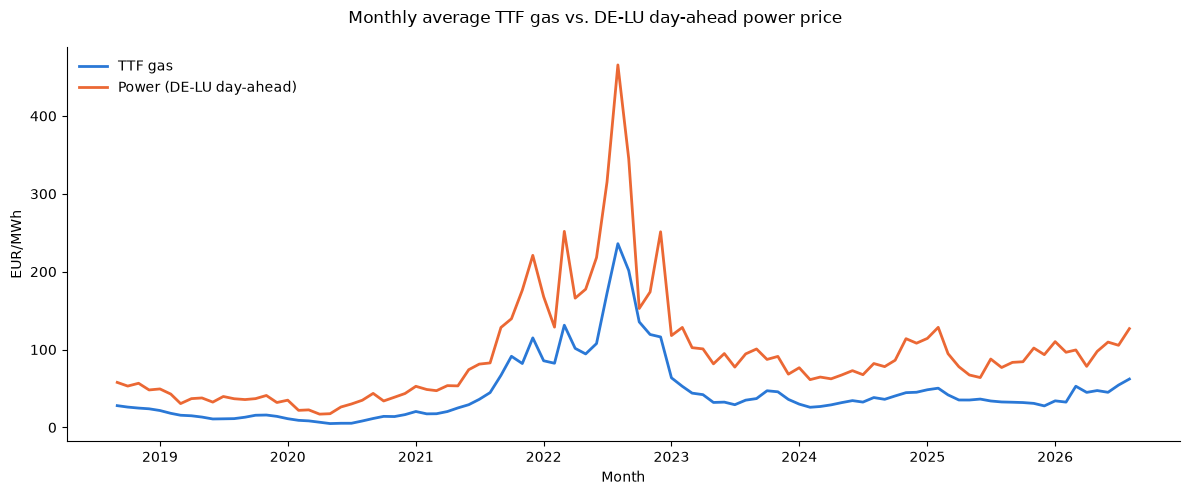

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly["ttf_gas_eur_mwh"], color=GAS_COLOR, linewidth=2, label="TTF gas")
ax.plot(monthly.index, monthly["power_de_lu_eur_mwh"], color=POWER_COLOR, linewidth=2, label="Power (DE-LU day-ahead)")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Month")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False)
fig.suptitle("Monthly average TTF gas vs. DE-LU day-ahead power price")
fig.tight_layout()
plt.show()

The 2021-2022 gas crisis stands out clearly on both series -- power prices
tracked gas upward almost one-for-one at the time, consistent with gas
being the marginal price setter through most of that period.

## Do the two move together?

A scatter of the same monthly pairs, plus their Pearson correlation --
a single overlay chart can look correlated just from both series trending
in the same direction over a few big episodes (like 2021-2022 above); the
correlation coefficient and the point cloud's scatter around a line are a
more direct read on how tight the relationship actually is month to month.

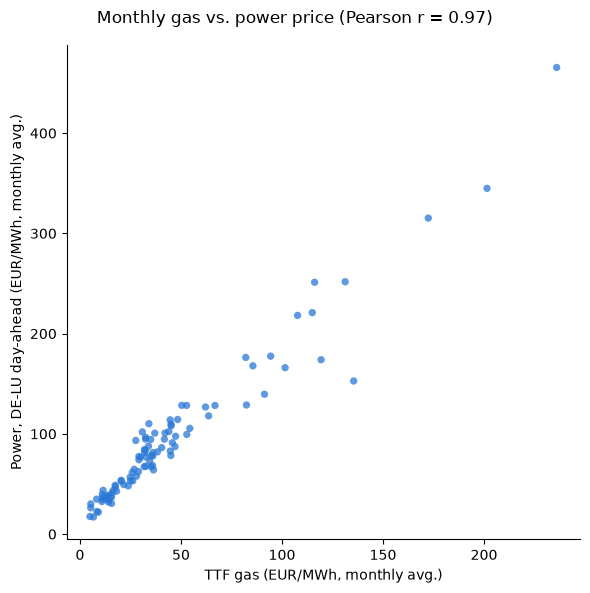

Pearson correlation, monthly averages: 0.97
Months compared: 96 (2018-09-01 to 2026-08-01)


In [5]:
correlation = monthly["ttf_gas_eur_mwh"].corr(monthly["power_de_lu_eur_mwh"])

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(monthly["ttf_gas_eur_mwh"], monthly["power_de_lu_eur_mwh"], color=GAS_COLOR, s=28, alpha=0.75, edgecolors="none")
ax.set_xlabel("TTF gas (EUR/MWh, monthly avg.)")
ax.set_ylabel("Power, DE-LU day-ahead (EUR/MWh, monthly avg.)")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(f"Monthly gas vs. power price (Pearson r = {correlation:.2f})")
fig.tight_layout()
plt.show()

print(f"Pearson correlation, monthly averages: {correlation:.2f}")
print(f"Months compared: {len(monthly)} ({monthly.index.min().date()} to {monthly.index.max().date()})")

## Spread over time

`power - gas`, in EUR/MWh -- both being in the same unit makes this
difference directly meaningful, not just a shape comparison. A widening
spread points at periods where something other than gas is driving power
prices (e.g. carbon prices, scarcity premia, or renewable-output effects
pulling the marginal price setter away from gas); a spread near zero is
consistent with gas-fired plants setting the day-ahead price close to
their own fuel cost.

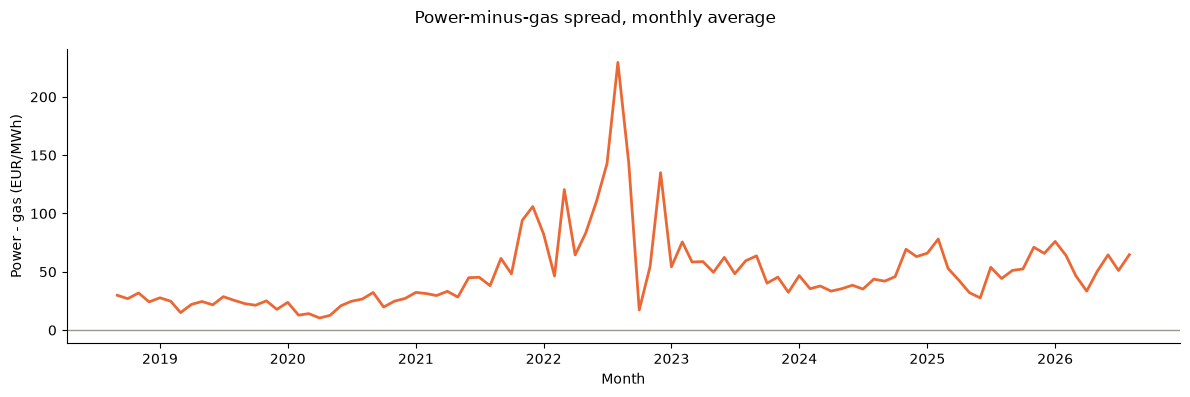

count     96.0
mean      49.2
std       33.3
min       10.4
25%       27.5
50%       43.2
75%       61.7
max      229.6
dtype: float64

In [6]:
spread = monthly["power_de_lu_eur_mwh"] - monthly["ttf_gas_eur_mwh"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.axhline(0, color="#9a9990", linewidth=1)
ax.plot(spread.index, spread, color=POWER_COLOR, linewidth=2)
ax.set_ylabel("Power - gas (EUR/MWh)")
ax.set_xlabel("Month")
ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Power-minus-gas spread, monthly average")
fig.tight_layout()
plt.show()

spread.describe().round(1)